In [1]:
!pip install uproot
import uproot

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 397.5/397.5 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 924.2/924.2 kB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 657.8/657.8 kB 26.7 MB/s eta 0:00:00


Viking.mac: /control/verbose 0

/control/execute /users/mw2304/geant4_apps/QEPET/build/quiet.mac

/process/em/QuantumEntanglement true

/run/numberOfThreads 1

'# To enable 3-gamma annihilations '#/process/em/setPositronAtRestModel OrePowellPolar'

'#/material/g4/ortoPositroniumFraction G4_AIR 1.0

'#/material/g4/ortoPositroniumFraction G4_WATER 1.0

'#/material/g4/ortoPositroniumFraction G4_BONE_COMPACT_ICRU 1.0

'# Activate/deactivate non-collinearity /QEPET/det/nonCollin false

/control/execute /users/mw2304/geant4_apps/QEPET/build/randomTissues.mac

/run/initialize

/control/execute /users/mw2304/geant4_apps/QEPET/build/fiveSphericalSources.mac

/run/beamOn 100000

In [2]:
import matplotlib.pyplot as plt

rootfile = uproot.open('FSStest.root')
print(rootfile.keys())

['NCS;1', 'PhantomSCS;1', 'ScannerSCS;1', 'PhantomSCS_ScannerSCS;1', 'PhantomDCS;1', 'ScannerDCS;1', 'PhantomSCS_ScannerDCS;1', 'PhantomDCS_ScannerSCS;1', 'PhantomDCS_ScannerDCS;1', 'MCS;1', 'Excluded;1']


In [3]:
tree = rootfile["NCS"]

print(tree.num_entries)

8239.0


In [4]:
tree = rootfile['NCS']
print(tree.keys())

['AnnihilX', 'AnnihilY', 'AnnihilZ', 'Gamma1_ScatterX', 'Gamma1_ScatterY', 'Gamma1_ScatterZ', 'Gamma1_Theta', 'Gamma1_HitE1', 'Gamma1_HitX1', 'Gamma1_HitY1', 'Gamma1_HitZ1', 'Gamma1_HitE2', 'Gamma1_HitX2', 'Gamma1_HitY2', 'Gamma1_HitZ2', 'Gamma2_ScatterX', 'Gamma2_ScatterY', 'Gamma2_ScatterZ', 'Gamma2_Theta', 'Gamma2_HitE1', 'Gamma2_HitX1', 'Gamma2_HitY1', 'Gamma2_HitZ1', 'Gamma2_HitE2', 'Gamma2_HitX2', 'Gamma2_HitY2', 'Gamma2_HitZ2', 'DeltaPhi']


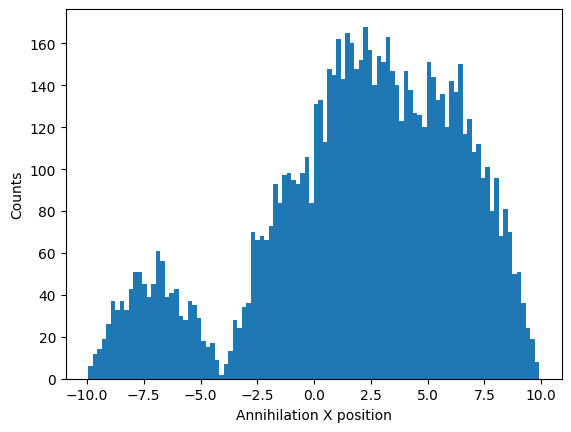

In [5]:
x = tree["AnnihilX"].array(library="np")
plt.hist(x, bins=100)
plt.xlabel("Annihilation X position")
plt.ylabel("Counts")
plt.show()

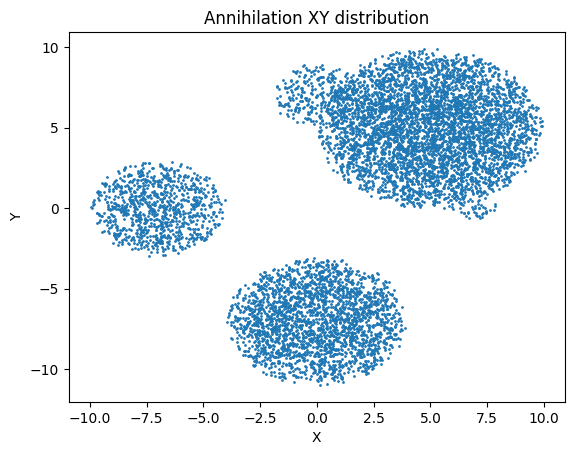

In [6]:
x = tree["AnnihilX"].array()
y = tree["AnnihilY"].array()

plt.scatter(x, y, s=1)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Annihilation XY distribution")
plt.show()

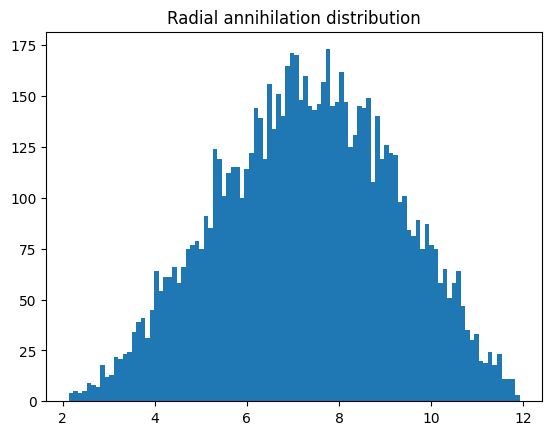

In [7]:
import numpy as np
r = np.sqrt(x**2 + y**2)

plt.hist(r, bins=100)
plt.title("Radial annihilation distribution")
plt.show()

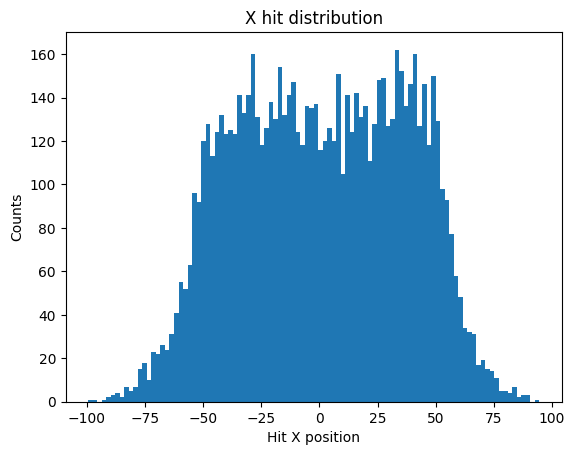

In [8]:
x = tree["Gamma1_HitX1"].array(library="np")

plt.hist(x, bins=100)
plt.xlabel("Hit X position")
plt.ylabel("Counts")
plt.title("X hit distribution")
plt.show()

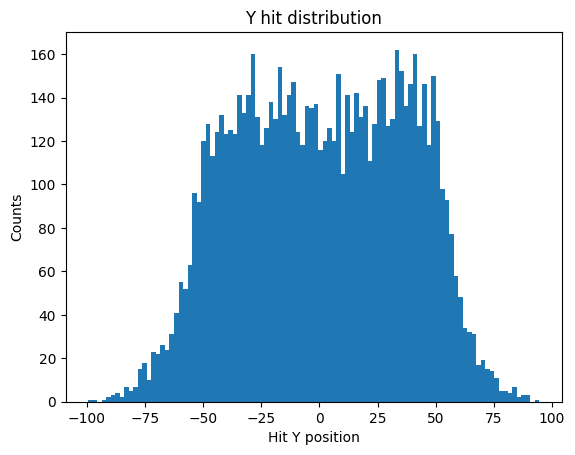

In [9]:
y = tree["Gamma1_HitY1"].array(library="np")

plt.hist(x, bins=100)
plt.xlabel("Hit Y position")
plt.ylabel("Counts")
plt.title("Y hit distribution")
plt.show()

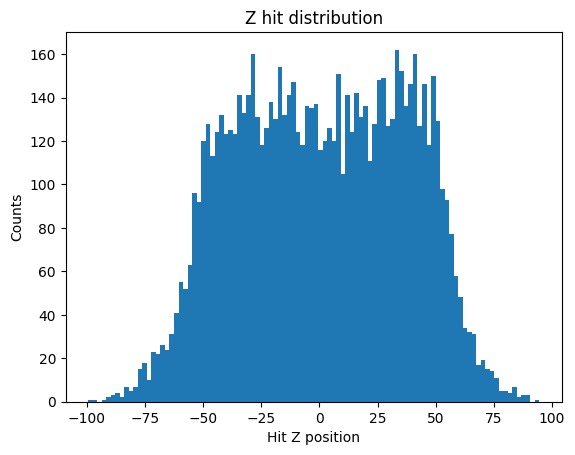

In [10]:
Z = tree["Gamma1_HitZ1"].array(library="np")

plt.hist(x, bins=100)
plt.xlabel("Hit Z position")
plt.ylabel("Counts")
plt.title("Z hit distribution")
plt.show()

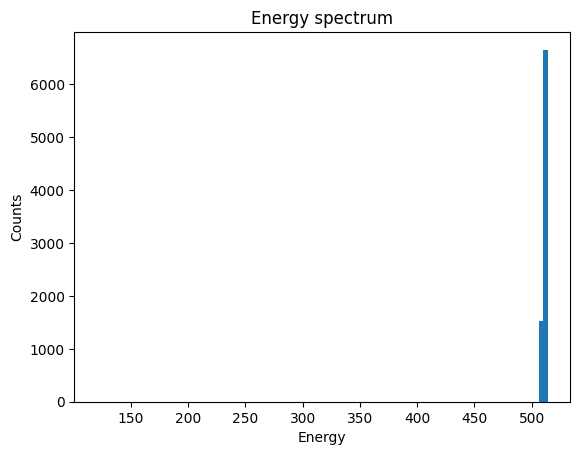

In [11]:
import uproot
import matplotlib.pyplot as plt

f = uproot.open("FSStest.root")
tree = f[list(f.keys())[0]]

energy = tree["Gamma1_HitE1"].array(library="np")

plt.hist(energy, bins=100)
plt.xlabel("Energy")
plt.ylabel("Counts")
plt.title("Energy spectrum")
plt.show()

In [12]:
f = uproot.open("FSStest.root")
tree = f["NCS"]

g1 = tree["Gamma1_Theta"].array(library="np")
g2 = tree["Gamma2_Theta"].array(library="np")

print(np.mean(g1))
print(np.mean(g2))
print(np.allclose(g1, g2))

0.0
0.0
True


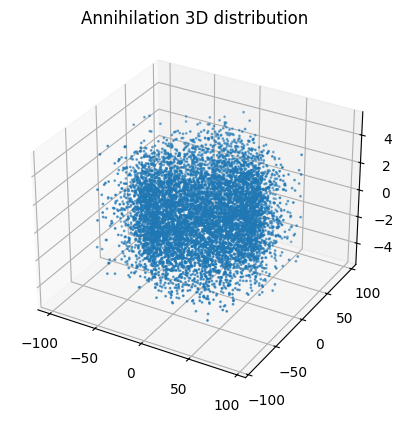

In [13]:
z = tree["AnnihilZ"].array(library="np")

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x, y, z, s=1)

ax.set_title("Annihilation 3D distribution")
plt.show()

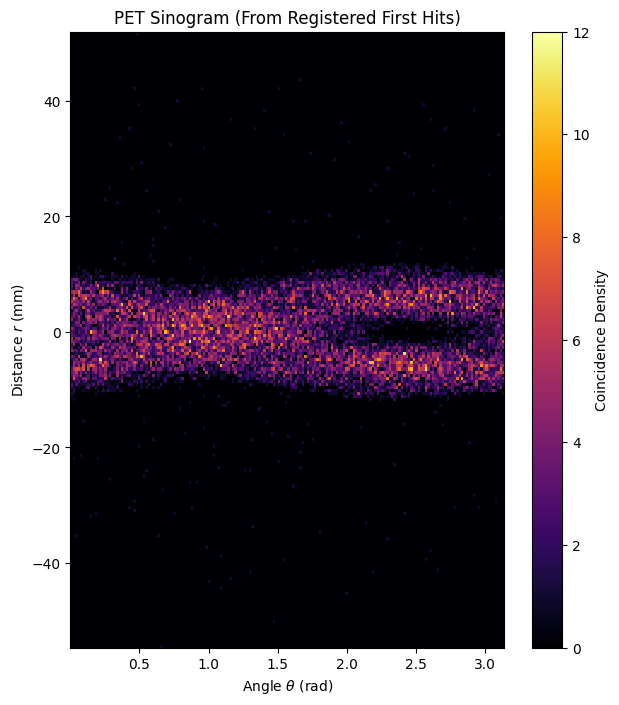

In [15]:
import uproot
import numpy as np
import matplotlib.pyplot as plt

file = uproot.open("FSStest.root")
tree = file["ScannerSCS;1"]

# Extract first hit locations for Gamma 1 and Gamma 2
data = tree.arrays(["Gamma1_HitX1", "Gamma1_HitY1", "Gamma2_HitX1", "Gamma2_HitY1"], library="np")
x1, y1 = data["Gamma1_HitX1"], data["Gamma1_HitY1"]
x2, y2 = data["Gamma2_HitX1"], data["Gamma2_HitY1"]

# Calculate the angle theta [0, pi] of the LOR
theta = np.mod(np.arctan2(y2 - y1, x2 - x1), np.pi)

# Calculate the perpendicular distance (r) from the origin to the LOR
r = (x1 * y2 - y1 * x2) / np.sqrt((x2 - x1)**2 + (y2 - y1)**2)

# Plot the Raw Sinogram
plt.figure(figsize=(7, 8))
plt.hist2d(theta, r, bins=[180, 200], cmap='inferno')
plt.title("PET Sinogram (From Registered First Hits)")
plt.xlabel(r"Angle $\theta$ (rad)")
plt.ylabel("Distance $r$ (mm)")
plt.colorbar(label="Coincidence Density")
plt.show()

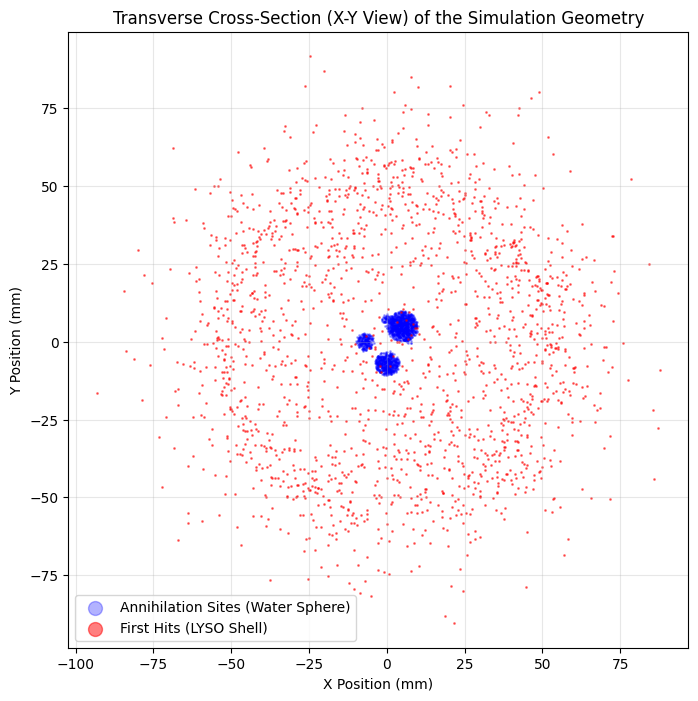

In [16]:
import uproot
import matplotlib.pyplot as plt

# Load the data
tree = uproot.open("FSStest.root")["ScannerSCS;1"].arrays(library="np")

# Extract coordinates
ax, ay = tree["AnnihilX"], tree["AnnihilY"]
hx, hy = tree["Gamma1_HitX1"], tree["Gamma1_HitY1"]

# Create the visual plot
plt.figure(figsize=(8, 8))

# 1. Plot the annihilation vertices (this outlines the inner water sphere)
plt.scatter(ax[::10], ay[::10], c='blue', s=1, alpha=0.3, label='Annihilation Sites (Water Sphere)')

# 2. Plot the detector hits (this outlines the outer LYSO crystal ring)
plt.scatter(hx[::10], hy[::10], c='red', s=1, alpha=0.5, label='First Hits (LYSO Shell)')

plt.title("Transverse Cross-Section (X-Y View) of the Simulation Geometry")
plt.xlabel("X Position (mm)")
plt.ylabel("Y Position (mm)")
plt.axis('equal') # Crucial to maintain correct aspect ratio for spheres/cylinders
plt.legend(markerscale=10)
plt.grid(True, alpha=0.3)
plt.show()

solid circle of blue dots in the center (the NEMA-NU4 water sphere) surrounded by a distinct, separate ring of red dots further out (the LYSO shell)

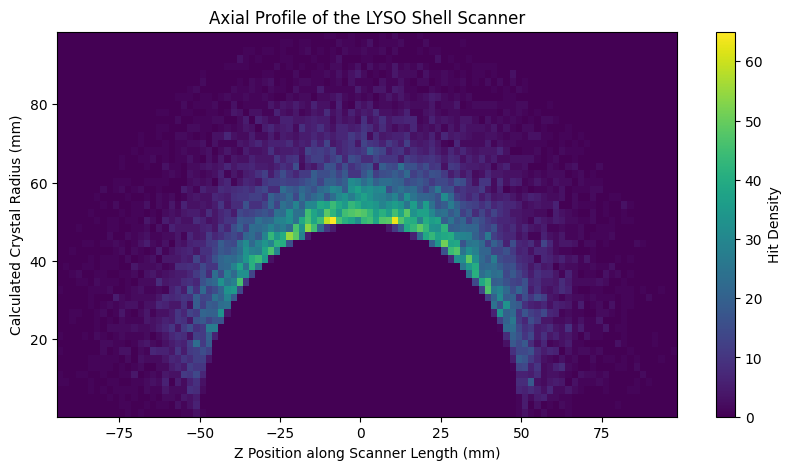

In [17]:
import uproot
import numpy as np
import matplotlib.pyplot as plt

tree = uproot.open("FSStest.root")["ScannerSCS;1"].arrays(library="np")

# Calculate the radius where the gamma ray hit the detector
hit_radius = np.sqrt(tree["Gamma1_HitX1"]**2 + tree["Gamma1_HitY1"]**2)
hit_z = tree["Gamma1_HitZ1"]

plt.figure(figsize=(10, 5))
# Use a 2D histogram to show the density of hits along the scanner body
plt.hist2d(hit_z, hit_radius, bins=[100, 50], cmap='viridis')

plt.title("Axial Profile of the LYSO Shell Scanner")
plt.xlabel("Z Position along Scanner Length (mm)")
plt.ylabel("Calculated Crystal Radius (mm)")
plt.colorbar(label="Hit Density")
plt.show()

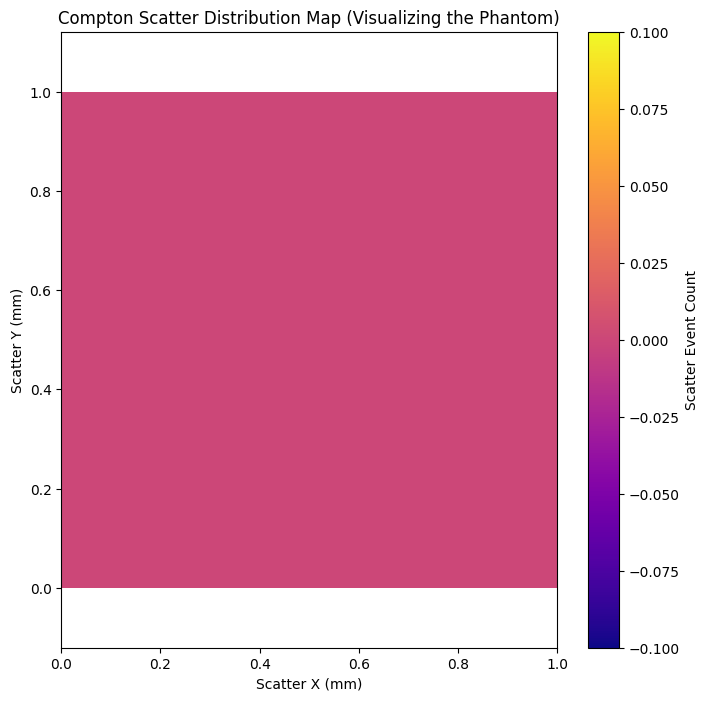

In [18]:
import uproot
import matplotlib.pyplot as plt

tree = uproot.open("FSStest.root")["ScannerSCS;1"].arrays(library="np")

# Filter out events that didn't scatter in the phantom (where coordinates are 0)
sx = tree["Gamma1_ScatterX"]
sy = tree["Gamma1_ScatterY"]
scatter_mask = (sx != 0) & (sy != 0)

plt.figure(figsize=(8, 8))
# Create a heatmap of the scatter locations
plt.hist2d(sx[scatter_mask], sy[scatter_mask], bins=100, cmap='plasma')

plt.title("Compton Scatter Distribution Map (Visualizing the Phantom)")
plt.xlabel("Scatter X (mm)")
plt.ylabel("Scatter Y (mm)")
plt.axis('equal')
plt.colorbar(label="Scatter Event Count")
plt.show()

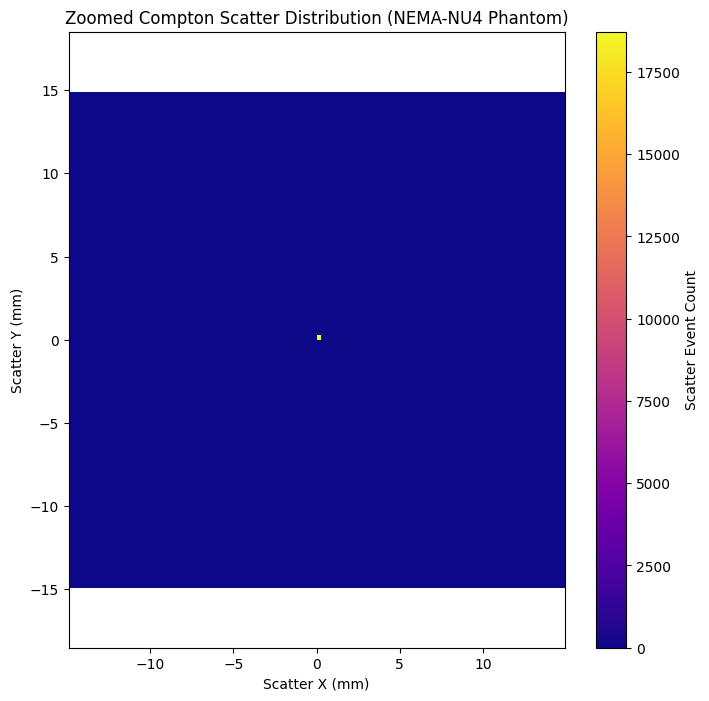

In [19]:
import uproot
import numpy as np
import matplotlib.pyplot as plt

tree = uproot.open("FSStest.root")["ScannerSCS;1"].arrays(library="np")

sx = tree["Gamma1_ScatterX"]
sy = tree["Gamma1_ScatterY"]

# Let's dynamically find where the real data clusters by looking at the annihilation coordinates
# A NEMA-NU4 phantom is typically small (radius ~25-50mm)
ax_max = np.max(np.abs(tree["AnnihilX"]))
display_limit = ax_max * 1.5 # Dynamically scale the window to fit the phantom size

# Filter out common extreme dummy values (like 9999 or -9999)
valid_mask = (np.abs(sx) < 2000) & (np.abs(sy) < 2000)

plt.figure(figsize=(8, 8))
# Use the 'range' argument to zoom into the phantom's physical area
plt.hist2d(sx[valid_mask], sy[valid_mask], bins=100,
           range=[[-display_limit, display_limit], [-display_limit, display_limit]],
           cmap='plasma')

plt.title("Zoomed Compton Scatter Distribution (NEMA-NU4 Phantom)")
plt.xlabel("Scatter X (mm)")
plt.ylabel("Scatter Y (mm)")
plt.axis('equal')
plt.colorbar(label="Scatter Event Count")
plt.show()